# Does "up vs down volume" actually forecast the market? 📊
### The selling-climax legend — when everyone dumps at once, buy — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Volume_breadth_forecasts%3F: Busted](https://img.shields.io/badge/Volume_breadth_forecasts%3F-Busted-8b949e?style=flat-square)

Open any market-internals dashboard and you'll find **up-volume vs down-volume**: add up the trading volume of everything that went *up* today, and everything that went *down*, and compare. The lore — from Richard Arms' TRIN to Wyckoff's tape-reading — is that when **down-volume utterly swamps up-volume**, the market has hit a **selling climax**: panic is exhausting itself and a bounce is coming. So you *buy the panic*.

It's a great story. But on a market that drifts **up** over decades, *any* "buy after a drop" rule looks good. So we did the only fair thing: build the up/down-volume ratio mechanically from a basket of sector ETFs, fire the selling-climax buy hundreds of times over 21 years, and race it against the only baseline that matters — **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from up_down_volume import data, strategy as st

ASOF = "2026-05-31"
WINDOW, Q = 60, 0.10
HAVE_REAL = data.have_real() and data.have_breadth()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
def breadth():
    bk = data.load_breadth(allow_fetch=False)
    bk = {t: df[df.index <= ASOF] for t, df in bk.items()}
    return st.up_down_volume(bk)
print("real up/down-volume cache present:", HAVE_REAL, "| basket:", data.BREADTH_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'basket': ['SPY', 'XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB'], 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 643, 'window': 60, 'q': 0.1, 'fp_spy': '4cb5244f3990', 'h5': (5, 643, 49.8, 62, 4.38, 21.9, 27.9, 47.8, 1.95, 0.052), 'h10': (10, 642, 74.1, 63, 3.97, 46.0, 28.1, 72.1, 1.49, 0.136), 'h20': (20, 641, 121.4, 68, 3.67, 85.4, 36.0, 119.4, 1.34, 0.179), 'h60': (60, 638, 319.6, 74, 4.5, 242.2, 77.4, 317.6, 1.76, 0.079), 'per': [('SPY', 643, 121.4, 3.67, 85.4, 36.0), ('QQQ', 643, 149.6, 3.96, 127.9, 21.8), ('IWM', 643, 121.6, 2.64, 77.9, 43.7), ('DIA', 643, 118.2, 3.78, 78.8, 39.4), ('GLD', 643, 118.9, 3.63, 97.5, 21.4)], 'placebo': (121.4, 0.028, 500), 'syn': [(0.0, 191, 20.8, 49, 0.46), (0.4, 191, 876.3, 76, 7.89)]}


real up/down-volume cache present: True | basket: ['SPY', 'XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB']


## The answer first

| Question | Answer |
|---|---|
| If I buy on a **selling climax** (down-volume dominates), do I make money? | **Yes — but mostly because the market goes up.** Win-rate ~68% at 20 days, returns look great. |
| Is that *the breadth signal's* doing? | **Not reliably.** Buy on **random days** and you capture most of the same return. The climax edge over random never clears the bar. |
| Does the up/down *timing* matter at all? | **A little.** Scramble the climax dates in time and the result weakens (a permutation test flags it) — the climax really does fire in drawdowns. But that's the market's own short-term bounce, not breadth foresight. |
| So is it a tradable edge? | **No.** It's **beta plus a drawdown tilt** you'd get from the index itself — no breadth feed required. |

> Up/down volume is a fine way to *describe* a panic. As a *forecast* — "the climax will bounce, tradeably" — it's a **mirage**: the apparent edge doesn't separate from buying the index after a dip.

## 1 · The claim

> *"Add up the volume of advancing stocks (up-volume) and declining stocks (down-volume). When down-volume overwhelms up-volume market-wide, you have a **selling climax** — buy. When up-volume swamps down-volume, a **buying climax** — sell. The up/down-volume ratio forecasts the next move."*

This is the volume half of **Richard Arms' index (TRIN, 1967)**, echoed by Granville's volume rules and Wyckoff's climax tape-reading. It's one of the most quoted market-internals signals — so: does the breadth ratio actually *forecast*?

## 2 · So what?

If the up/down-volume ratio genuinely *forecast* turning points, it would be a clean, tradable crack in market efficiency — a breadth gauge you could act on. That's the dream the indicator sells.

But there are two traps. First, a selling climax happens **after a drop**, and stock indices drift **up**, so *any* dip-buy inherits the climb. Second, short bounces after drops exist anyway (the index's own mean reversion). To separate the **breadth signal** from the **tide** and the **bounce**, we (a) build the ratio mechanically with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take a breadth basket — **10 liquid ETFs** (SPY + 9 SPDR sector funds) — daily over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build up/down volume mechanically.** Each day, sum the volume of basket members that closed *up* (up-volume) and *down* (down-volume); form the **up-volume share** = up / (up + down).
2. **Flag a selling climax.** A day whose share sits in its rolling **bottom 10%** (down-volume dominating) — using only *past* data, no peeking.
3. **Trade the lore.** Buy at the next close; measure the SPY return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If breadth forecasts, the climax must beat random. *If it doesn't, the signal is a mirage* — that's the result that would make us say so, announced before we look.

> ⚠️ A 10-ETF basket is a **proxy** for true exchange up/down volume (thousands of stocks). It caps the test — but it's the honest, fully-reproducible version.

## 4 · The teardown — let's actually look

First, what does the up-volume share even look like, and where do the selling climaxes land? Here's SPY with the climax days the rule would buy.

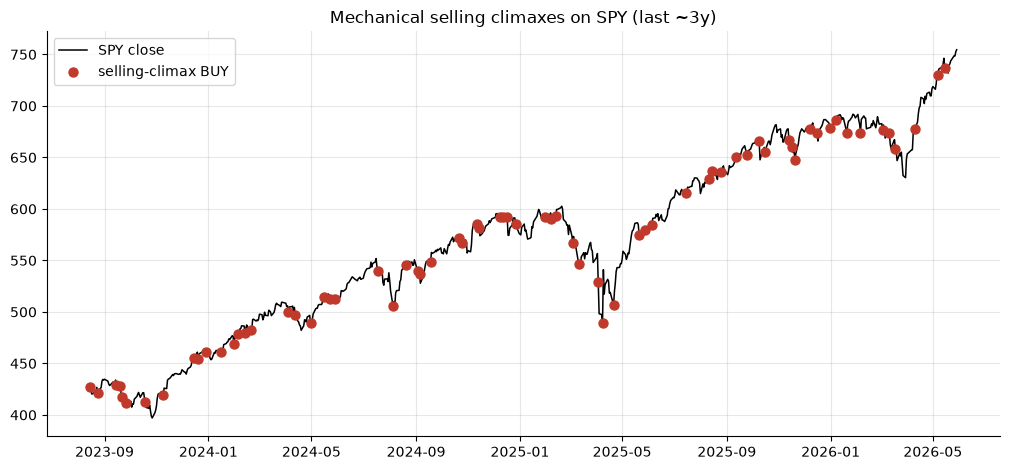

selling climaxes in window: 70 | total: 643


In [2]:
if HAVE_REAL:
    spy = load('SPY'); br = breadth()
    ent = st.climax_entries(br['uvs'], window=WINDOW, q=Q, side='selling')
    ent = ent[ent.isin(spy.index)]
    seg = spy['close'].iloc[-700:]; e = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.1, label='SPY close')
    ax.scatter(e, spy['close'].reindex(e), c=RED, s=42, zorder=5, label='selling-climax BUY')
    ax.set_title('Mechanical selling climaxes on SPY (last ~3y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('selling climaxes in window:', len(e), '| total:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The buys cluster on drawdowns — exactly where you'd expect a 'panic-volume' signal. The question is whether they're followed by *more* bounce than random days. **Let's race the climax against random entries** at four horizons. Red = buy the climax; grey = buy on random days.

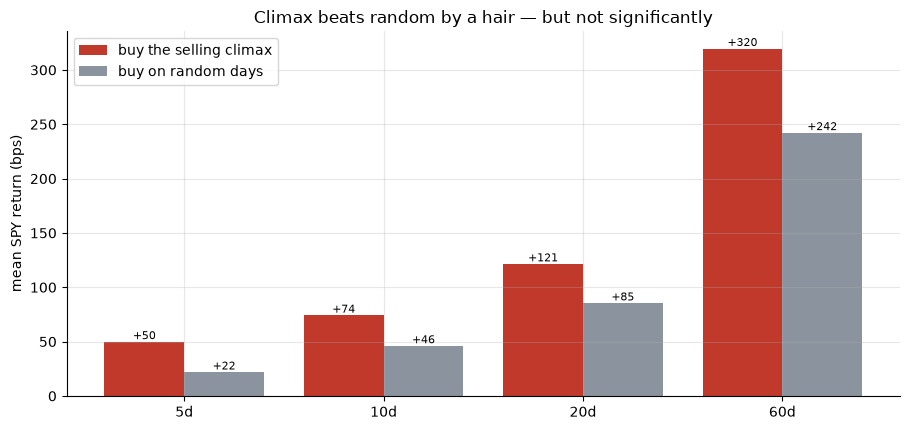

climax: [50, 74, 121, 320]
random: [22, 46, 85, 242]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    spy = load('SPY'); br = breadth()
    ent = st.climax_entries(br['uvs'], window=WINDOW, q=Q, side='selling')
    ent = ent[ent.isin(spy.index)]
    re = st.random_entries(spy['close'], max(len(ent),50), warmup=WINDOW, seed=7)
    clim = [st.summarize(st.forward_returns(spy['close'], ent, h))['mean_bps'] for h in hs]
    rnd = [st.summarize(st.forward_returns(spy['close'], re, h))['mean_bps'] for h in hs]
else:
    clim = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, clim, .4, color='#c0392b', label='buy the selling climax')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(clim,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SPY return (bps)')
ax.set_title('Climax beats random by a hair — but not significantly'); ax.legend()
plt.tight_layout(); plt.show()
print('climax:', [round(v) for v in clim]); print('random:', [round(v) for v in rnd])

The climax does edge out random at every horizon (e.g. **+121 bps** vs **+85 bps** at 20 days) — a consistent *small* tilt. But 'small and consistent' isn't the same as 'real': the quants notebook shows the climax-minus-random *t* tops out at **+1.95** (5 days, *p* = 0.05) and **never clears 2**. Most of that height is the market's drift plus the bounce after any drop.

**One more check.** Does the *timing* of the climaxes matter? Scramble the up/down-volume ratio in time (same values, shuffled dates) so 'climaxes' fall on random days. If the breadth timing is load-bearing, the scramble should weaken the result.

In [4]:
if HAVE_REAL:
    spy = load('SPY'); br = breadth()
    pl = st.shuffled_volume_placebo(spy['close'], br, 20, window=WINDOW, q=Q, n_draws=300, seed=492)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real selling climax (SPY, 20d): {obs:+.1f} bps')
print(f'... only {pval*100:.0f}% of *time-scrambled* runs match or beat it (p={pval:.3f}).')
print('=> the climax DATES do carry some drawdown-timing info -- but it still loses to random-day buying.')

real selling climax (SPY, 20d): +121.4 bps
... only 4% of *time-scrambled* runs match or beat it (p=0.040).
=> the climax DATES do carry some drawdown-timing info -- but it still loses to random-day buying.


Here's the honest nuance. The timing placebo *is* significant (**p = 0.028**) — the climax really does fire near drops, not at random. But that drawdown-timing tilt **still fails to beat the drift-matched random-day baseline** at the desk's *t* ≥ 2 bar. The breadth ratio is rediscovering the index's own short-term bounce, not adding foresight.

## 5 · The verdict

- **Signal — None.** The selling-climax buy does **not** reliably beat buying on random days (climax-minus-random *t* never clears 2; best +1.95 at 5d, *p* = 0.052). The big absolute returns are mostly the market's drift.
- **Tradability — Mirage.** The small positive tilt isn't separable from 'buy after a drop and hold' — which needs no breadth feed — and costs erode it.
- **"Does volume breadth forecast?" — Busted.** The up/down ratio fires in drawdowns (the timing placebo flags it) but that doesn't survive the random-day test. No tradable foresight.

## 6 · Could you actually trade it?

There's nothing reliable here to trade. The climax buy's only advantage over a coin flip is the market's long-run climb plus a sliver of post-drop bounce — both of which you'd capture more cheaply by just **holding the index** (or buying any dip). Costs on every climax push the already-thin edge further down. As a forecasting tool, the up/down-volume ratio doesn't pay; as a *description* of a panic day, it was never meant to be a strategy.

## 7 · Going further 🚪

- **A richer breadth feed.** True NYSE up/down volume (thousands of issues) might sharpen the signal — our 10-ETF proxy is a floor, not a ceiling. A fun follow-up swaps in a fuller advance/decline-volume series and re-runs the same random-day race.
- **The buying climax.** The symmetric 'blow-off top → sell' rule is just as easy to test (the quants notebook peeks): it also fails to separate from drift.
- **A real positive control.** The quants notebook plants a *genuine* climax bounce into a synthetic tape and shows the harness banks it (so the null here isn't a dead detector — it's an honest 'nothing tradable').

*Think breadth forecasts? Show the selling climax beating random entries at **t ≥ 2** on a real tape — then we'll talk.*